# Titanic Analysis

**Dataset Source**: [Titanic dataset](https://www.kaggle.com/competitions/titanic/data)


## 1. Data Loading and Preprocessing

In this section, we load the dataset and prepare it for analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_data = pd.read_csv("train.csv")

In [3]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
survivors_by_cabin = titanic_data.groupby("Cabin")["Survived"].sum()
sorted_by_cabin_desc = survivors_by_cabin.sort_values(ascending=False)
print(sorted_by_cabin_desc)

Cabin
B96 B98            4
F33                3
E101               3
B5                 2
B57 B59 B63 B66    2
                  ..
E63                0
F G63              0
F G73              0
F38                0
T                  0
Name: Survived, Length: 147, dtype: int64


In [5]:
titanic_data.drop(["Cabin"], axis=1, inplace=True)

## 2. Key Dataset Characteristics:

1.  **Survival Rate:** 38.38%
2.  **Gender:** Male: 64.76%, Female: 35.24%
3.  **Passenger Class:** 1st: 24%, 2nd: 20%, 3rd: 55%
4.  **Embarkation Ports:** C (Cherbourg), Q (Queenstown), S (Southampton)
5.  **With Siblings/Spouses:** 31.76%
6.  **With Parents/Children:** 23.91%
7.  **Median age** is 28

In [47]:
survived_people_percentage = titanic_data["Survived"].sum() / titanic_data["Survived"].count() * 100
print(f"Survived people percentage: {survived_people_percentage}%")

sex_counts = titanic_data["Sex"].value_counts()
male = sex_counts["male"]
female = sex_counts["female"]
print(f"Male: {male / (male + women) * 100:.2f}%, Femal: {women / (male + women) * 100:.2f}%")

print()
survival_rate_by_class = titanic_data.groupby("Pclass")["Survived"].mean() * 100
print(f"{survival_rate_by_class}")
print()
amount_of_people_with_siblings_percentage = titanic_data["SibSp"].value_counts()[1:].sum() / titanic_data["SibSp"].count() * 100
print(f"Percentage of people with siblings/spouses: {amount_of_people_with_siblings_percentage:.2f}%")

amount_of_people_with_parents_or_children_percentage = titanic_data["Parch"].value_counts()[1:].sum() / titanic_data["Parch"].count() * 100
print(f"Percentage of people with parents/children: {amount_of_people_with_parents_or_children_percentage:.2f}%")

median_age = titanic_data["Age"].median()
print(f"Median age: {median_age}")

Survived people percentage: 38.38383838383838%
Male: 64.76%, Femal: 35.24%

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Percentage of people with siblings/spouses: 31.76%
Percentage of people with parents/children: 23.91%
Median age: 28.0


# 📊 Insights from Titanic Data Analysis

## 1. Survival Rates by Passenger Class
- **1st Class**: **63%** survival rate  
- **2nd Class**: **47%** survival rate  
- **3rd Class**: **24%** survival rate  
-**Key Takeaway**: Wealthier passengers (higher classes) had a significantly higher chance of survival, likely due to better access to lifeboats and proximity to the deck.

## 2. Survival Rates by Gender
- **Females**: **68%** survival rate  
- **Males**: **32%** survival rate  
-**Key Takeaway**: Females had a much higher survival rate than males, reflecting the "women and children first" protocol during the evacuation.

## 3. Impact of Family Structure on Survival
### Females
- Having both siblings and parents/children on board was linked to the lowest survival rates for females.

| **Family Structure**            | **Survival Rate** |
|---------------------------------|-------------------|
| No Siblings, No Parents/Children | ~79%             |
| No Siblings, With Parents/Children | ~79%           |
| With Siblings, No Parents/Children | ~79%           |
| With Siblings, With Parents/Children | ~58%         |

### Males
- Having parents/children on board boosted survival rates for males, especially when they had no siblings.

| **Family Structure**            | **Survival Rate** |
|---------------------------------|-------------------|
| No Siblings, No Parents/Children | ~16%             |
| No Siblings, With Parents/Children | ~39%           |
| With Siblings, No Parents/Children | ~22%           |
| With Siblings, With Parents/Children | ~29%         |

**Key Takeaway**: Family dynamics played a role in survival. For females, larger family groups (siblings and parents/children) reduced survival chances, possibly due to challenges in evacuation. For males, having parents/children (but not siblings) improved survival, perhaps indicating they were prioritized as part of family units.

## 4. Survival Rates by Age Group
Survival rates generally decline with age, with notable patterns across age groups:  
- **0-20 and 20-30 Age Groups**: Highest survival rates, likely due to prioritization of younger passengers.  
- **30-40 Age Group**: Still relatively high survival rates, but slightly lower than younger groups.  
- **After Age 40**: Sharp drop in survival rates, suggesting older passengers were less likely to survive.  

**Key Takeaway**: Younger passengers had a better chance of survival, possibly due to physical ability to evacuate or prioritization during rescue efforts.

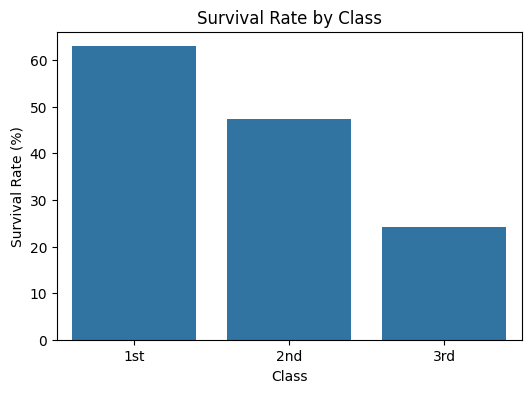

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [53]:
survivors_by_class = titanic_data.groupby("Pclass")["Survived"].sum()
amount_by_class = titanic_data.groupby("Pclass")["Survived"].count()
survivors_by_class_percentage = (survivors_by_class / amount_by_class) * 100

survival_df = survivors_by_class_percentage.reset_index()
survival_df.columns = ['Pclass', 'Survival Rate (%)']

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survival Rate (%)', data=survival_df)
plt.title('Survival Rate by Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(ticks=[0, 1, 2], labels=['1st', '2nd', '3rd'])

plt.show()
print(survivors_by_class_percentage)

In [43]:
survivors_by_gender = titanic_data.groupby("Sex")["Survived"].sum() / titanic_data["Survived"].sum() * 100
print(survivors_by_gender)

Sex
female    68.128655
male      31.871345
Name: Survived, dtype: float64


In [14]:
correlation = titanic_data["Pclass"].corr(titanic_data["Sex"].map({"male":1, "female":0}))
print(correlation)

0.13190049060473968


<Axes: xlabel='Sex'>

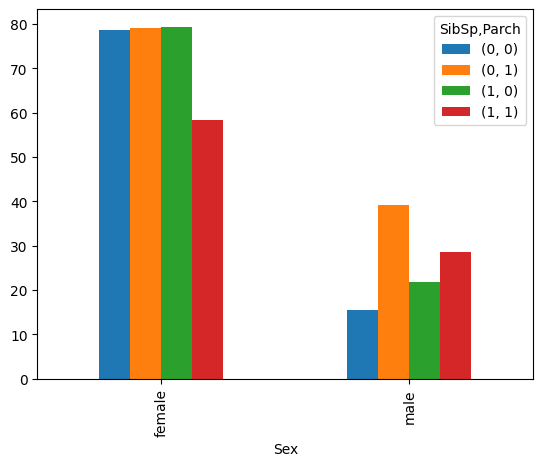

In [63]:
survivors_and_siblings = pd.crosstab(titanic_data["Sex"],
                                     [titanic_data["SibSp"].apply(lambda x: 1 if x > 0 else 0),
                                     titanic_data["Parch"].apply(lambda x: 1 if x > 0 else 0)],
                                     values = titanic_data["Survived"], aggfunc="sum"
                                     )

total_individuals = pd.crosstab(
    titanic_data["Sex"],
    [titanic_data["SibSp"].apply(lambda x: 1 if x > 0 else 0),
    titanic_data["Parch"].apply(lambda x: 1 if x > 0 else 0)]
    )

survivors_and_siblings_percentage = (survivors_and_siblings / total_individuals) * 100

survivors_and_siblings_percentage.plot.bar()

<ipython-input-55-135b6849d76c>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survivors_by_age_group = titanic_data.groupby("Age_group")["Survived"].sum()


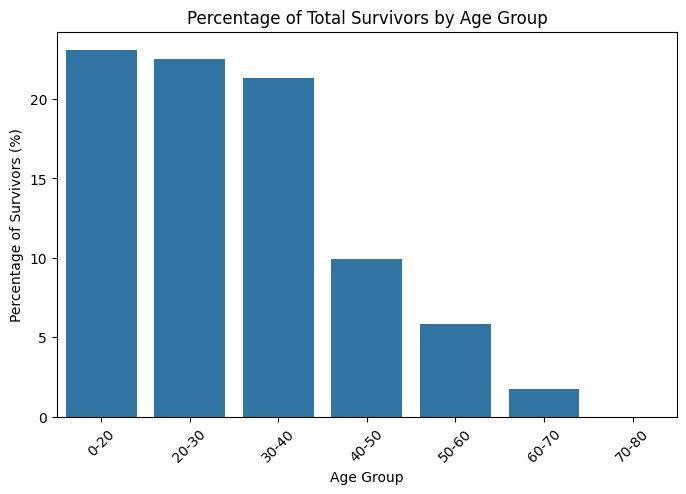

Age_group
0-20     23.099415
20-30    22.514620
30-40    21.345029
40-50     9.941520
50-60     5.847953
60-70     1.754386
70-80     0.000000
Name: Survived, dtype: float64


In [55]:
bins = [0, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']

titanic_data["Age_group"] = pd.cut(titanic_data["Age"], bins=bins, labels=labels, right=False)

survivors_by_age_group = titanic_data.groupby("Age_group")["Survived"].sum()
survivors_by_age_group_percentage = (survivors_by_age_group / titanic_data["Survived"].sum()) * 100

survival_df = survivors_by_age_group_percentage.reset_index()
survival_df.columns = ['Age Group', 'Percentage of Survivors (%)']

plt.figure(figsize=(8, 5))
sns.barplot(x='Age Group', y='Percentage of Survivors (%)', data=survival_df)
plt.title('Percentage of Total Survivors by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Survivors (%)')
plt.xticks(rotation=45)
plt.show()

print(survivors_by_age_group_percentage)

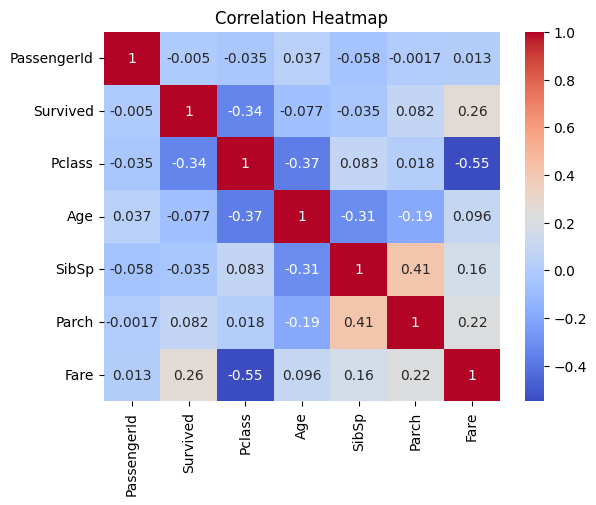

In [46]:
sns.heatmap(titanic_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

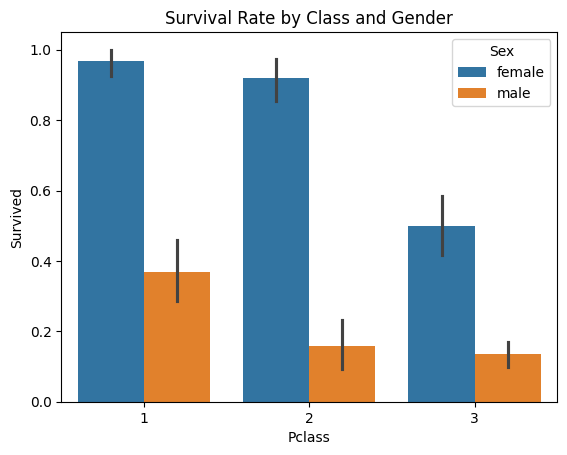

In [57]:
sns.barplot(data=titanic_data, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.show()